# Exploracion del dataset Student Performance

Este notebook carga directamente desde Kaggle el dataset [Student Performance](https://www.kaggle.com/datasets/nikhil7280/student-performance-multiple-linear-regression/data), revisa su estructura y obtiene estadísticas descriptivas básicas.

Se utiliza `kagglehub` con el adaptador de pandas y se fija la versión 1 para reproducir los experimentos. No hace falta descargar el CSV manualmente: la biblioteca lo obtiene y mantiene una copia en su caché local. La primera carga requiere conexión a Internet.

Instala las dependencias con `python -m pip install -r requirements.txt` antes de ejecutar el notebook.

In [4]:
import pandas as pd
import numpy as np

In [5]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

DATASET = "nikhil7280/student-performance-multiple-linear-regression/versions/1"
df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    DATASET,
    "Student_Performance.csv",
)

df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


## Estructura del dataset

In [6]:
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")

Filas: 10000
Columnas: 6


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  str    
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), str(1)
memory usage: 468.9 KB


In [8]:
df.dtypes

Hours Studied                         int64
Previous Scores                       int64
Extracurricular Activities              str
Sleep Hours                           int64
Sample Question Papers Practiced      int64
Performance Index                   float64
dtype: object

## Estadisticas descriptivas

In [9]:
estadisticas = df.describe(include="all")
estadisticas

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000,10000.000000,10000.000000,10000.000000
unique,NaN,NaN,2,NaN,NaN,NaN
top,NaN,NaN,No,NaN,NaN,NaN
freq,NaN,NaN,5052,NaN,NaN,NaN
mean,4.992900,69.445700,NaN,6.530600,4.583300,55.224800
std,2.589309,17.343152,NaN,1.695863,2.867348,19.212558
min,1.000000,40.000000,NaN,4.000000,0.000000,10.000000
25%,3.000000,54.000000,NaN,5.000000,2.000000,40.000000
50%,5.000000,69.000000,NaN,7.000000,5.000000,55.000000
75%,7.000000,85.000000,NaN,8.000000,7.000000,71.000000


In [10]:
estadisticas_numericas = df.describe().loc[["mean", "std", "min", "max"]]
estadisticas_numericas

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
mean,4.992900,69.445700,6.530600,4.583300,55.224800
std,2.589309,17.343152,1.695863,2.867348,19.212558
min,1.000000,40.000000,4.000000,0.000000,10.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


## Analisis exploratorio de datos (EDA)

El objetivo de prediccion es `Performance Index`. Se analizan sus relaciones con las caracteristicas numericas y la distribucion de la variable categorica.

In [11]:
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
variables_numericas = df.select_dtypes(include="number").columns.tolist()
target = "Performance Index"
caracteristicas_numericas = [col for col in variables_numericas if col != target]

### Histogramas de las variables numericas

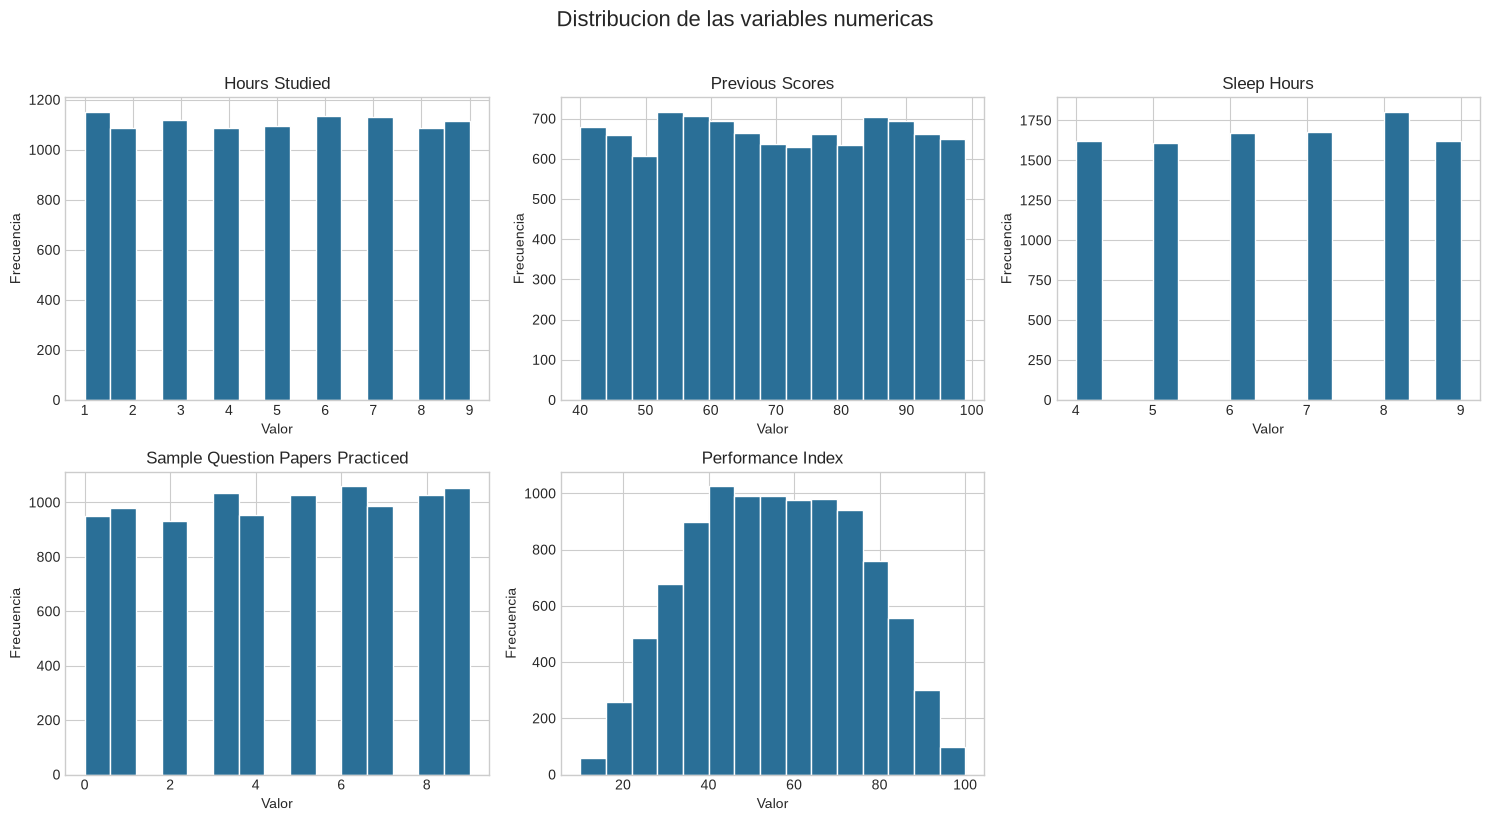

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, columna in zip(axes.flat, variables_numericas):
    ax.hist(df[columna], bins=15, color="#2a6f97", edgecolor="white")
    ax.set_title(columna)
    ax.set_xlabel("Valor")
    ax.set_ylabel("Frecuencia")

axes.flat[-1].set_visible(False)
fig.suptitle("Distribucion de las variables numericas", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

### Boxplots y valores atipicos

Se usa el criterio del rango intercuartil (IQR): un valor es atipico si es menor que `Q1 - 1.5 * IQR` o mayor que `Q3 + 1.5 * IQR`.

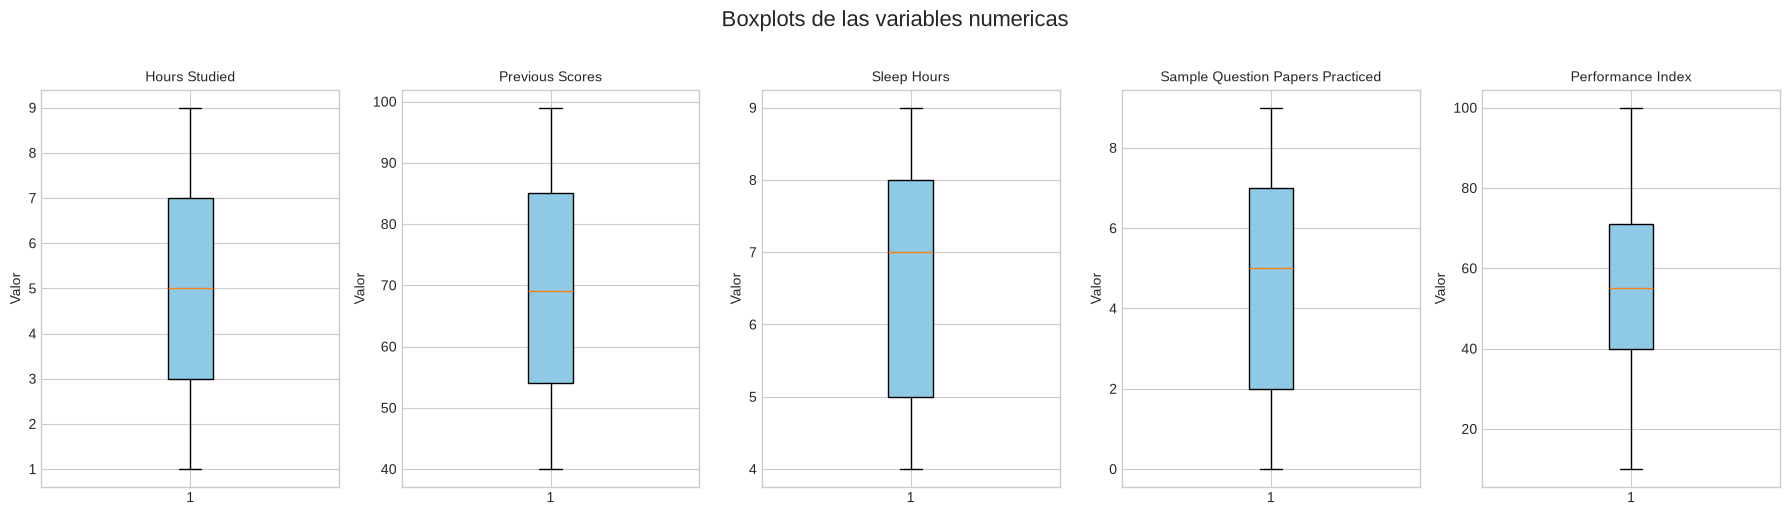

In [13]:
fig, axes = plt.subplots(1, len(variables_numericas), figsize=(18, 5))
for ax, columna in zip(axes, variables_numericas):
    ax.boxplot(df[columna], patch_artist=True, boxprops={"facecolor": "#8ecae6"})
    ax.set_title(columna, fontsize=10)
    ax.set_ylabel("Valor")

fig.suptitle("Boxplots de las variables numericas", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [14]:
q1 = df[variables_numericas].quantile(0.25)
q3 = df[variables_numericas].quantile(0.75)
iqr = q3 - q1
limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr
mascara_atipicos = df[variables_numericas].lt(limite_inferior) | df[variables_numericas].gt(limite_superior)

reporte_atipicos = pd.DataFrame({
    "Limite inferior": limite_inferior,
    "Limite superior": limite_superior,
    "Cantidad de atipicos": mascara_atipicos.sum(),
    "Porcentaje (%)": (mascara_atipicos.mean() * 100).round(2)
})
reporte_atipicos

,Limite inferior,Limite superior,Cantidad de atipicos,Porcentaje (%)
Hours Studied,-3.0,13.0,0,0.0
Previous Scores,7.5,131.5,0,0.0
Sleep Hours,0.5,12.5,0,0.0
Sample Question Papers Practiced,-5.5,14.5,0,0.0
Performance Index,-6.5,117.5,0,0.0


**Conclusion sobre datos atipicos:** no se identificaron valores atipicos con el criterio IQR en ninguna variable numerica. Los minimos y maximos observados se encuentran dentro de limites plausibles para las escalas del dataset. Por ello, no se eliminan ni se imputan registros; se conserva una copia del dataset original para el analisis posterior.

In [15]:
df_limpio = df.copy()
print(f"Registros antes del tratamiento: {len(df)}")
print(f"Registros despues del tratamiento: {len(df_limpio)}")

Registros antes del tratamiento: 10000
Registros despues del tratamiento: 10000


### Diagramas de dispersion: caracteristicas numericas frente al objetivo

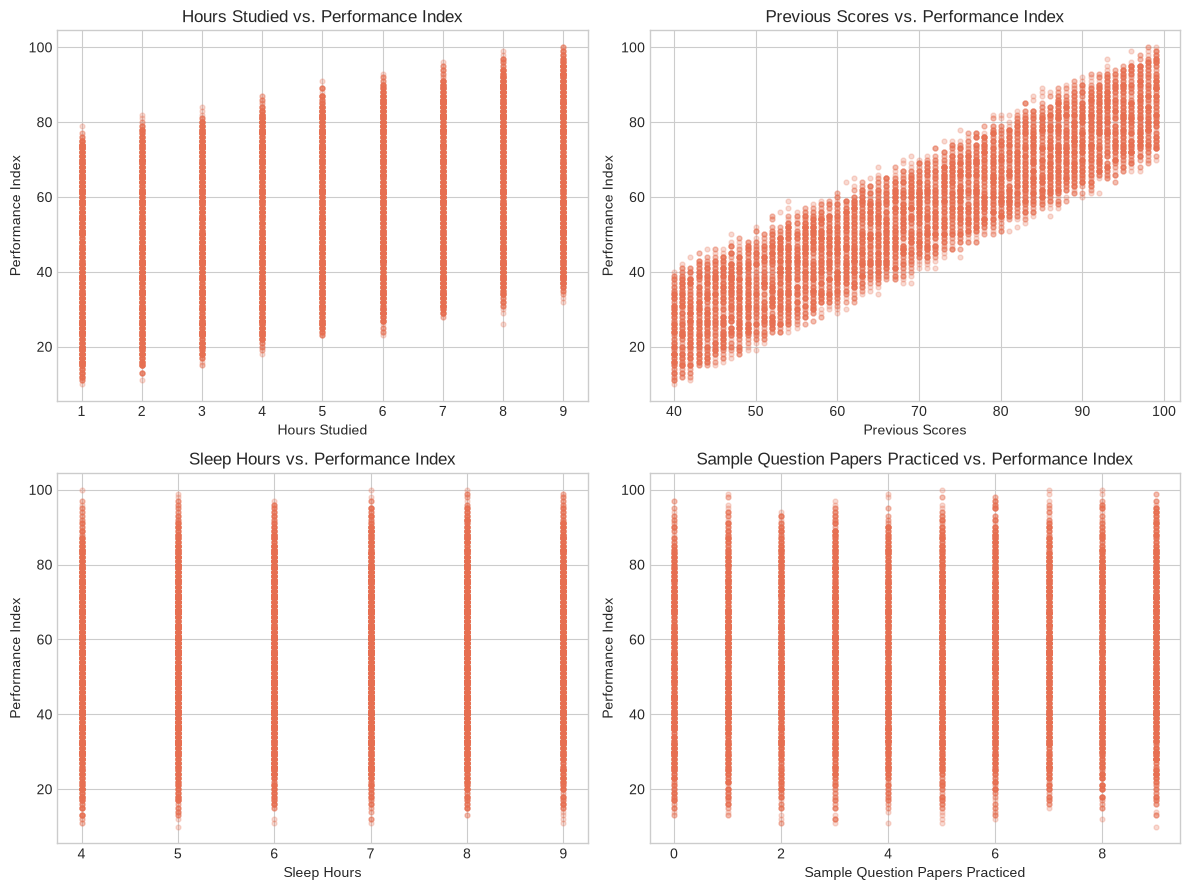

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, columna in zip(axes.flat, caracteristicas_numericas):
    ax.scatter(df_limpio[columna], df_limpio[target], alpha=0.25, s=12, color="#e76f51")
    ax.set_title(f"{columna} vs. {target}")
    ax.set_xlabel(columna)
    ax.set_ylabel(target)

plt.tight_layout()
plt.show()

### Actividades extracurriculares y rendimiento

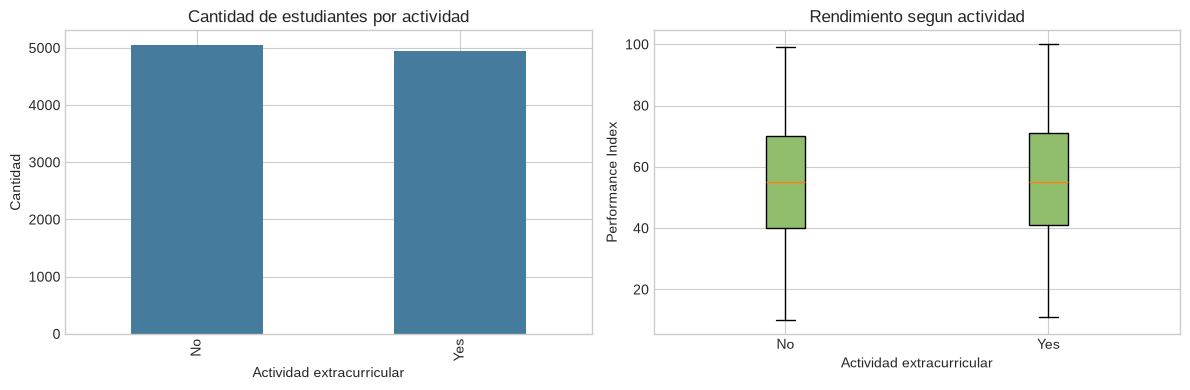

,count,mean,median,std
Extracurricular Activities,,,,
No,5052,54.76,55.0,19.15
Yes,4948,55.70,55.0,19.26


In [17]:
orden_actividad = ["No", "Yes"]
grupos_actividad = [
    df_limpio.loc[df_limpio["Extracurricular Activities"] == categoria, target]
    for categoria in orden_actividad
]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df_limpio["Extracurricular Activities"].value_counts().reindex(orden_actividad).plot(
    kind="bar", ax=axes[0], color="#457b9d"
)
axes[0].set_title("Cantidad de estudiantes por actividad")
axes[0].set_xlabel("Actividad extracurricular")
axes[0].set_ylabel("Cantidad")

axes[1].boxplot(grupos_actividad, tick_labels=orden_actividad, patch_artist=True, boxprops={"facecolor": "#90be6d"})
axes[1].set_title("Rendimiento segun actividad")
axes[1].set_xlabel("Actividad extracurricular")
axes[1].set_ylabel(target)

plt.tight_layout()
plt.show()

df_limpio.groupby("Extracurricular Activities")[target].agg(["count", "mean", "median", "std"]).round(2)

### Matriz de correlacion y mapa de calor

La correlacion de Pearson permite cuantificar la relacion lineal entre las variables numericas.

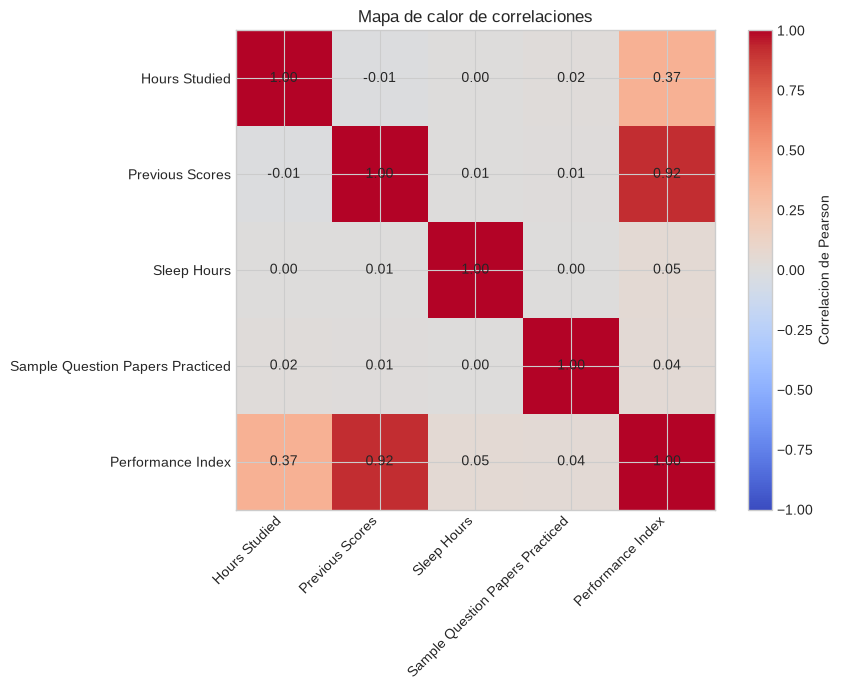

Performance Index                   1.000000
Previous Scores                     0.915189
Hours Studied                       0.373730
Sleep Hours                         0.048106
Sample Question Papers Practiced    0.043268
Name: Performance Index, dtype: float64

In [18]:
matriz_correlacion = df_limpio[variables_numericas].corr()

fig, ax = plt.subplots(figsize=(9, 7))
imagen = ax.imshow(matriz_correlacion, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(variables_numericas)), variables_numericas, rotation=45, ha="right")
ax.set_yticks(range(len(variables_numericas)), variables_numericas)

for fila in range(len(variables_numericas)):
    for columna in range(len(variables_numericas)):
        ax.text(columna, fila, f"{matriz_correlacion.iloc[fila, columna]:.2f}", ha="center", va="center")

fig.colorbar(imagen, ax=ax, label="Correlacion de Pearson")
ax.set_title("Mapa de calor de correlaciones")
plt.tight_layout()
plt.show()

matriz_correlacion[target].sort_values(ascending=False)

### Hallazgos principales

- `Previous Scores` presenta la relacion lineal positiva mas marcada con `Performance Index`, como se observa en el diagrama de dispersion y en la matriz de correlacion.
- `Hours Studied` tambien muestra una asociacion positiva con el rendimiento.
- Las restantes caracteristicas exhiben asociaciones mas moderadas, por lo que pueden aportar informacion complementaria a un modelo de regresion.
- No hay valores faltantes ni valores atipicos segun IQR; el dataset se mantiene sin eliminacion de registros.

## División del dataset (Random Sampling)

El objetivo de la sección es dividir el conjunto de datos del dataset en: 70% entrenamiento, 15% validación y 15% prueba. Además de lograr esto sin utilizar funciones de `scikit-learn` como `train_test_split`. Este procedimiento barajea las posiciones de las filas mediante una permutación generada con NumPy y corta esa permutación en tres tramos.

In [19]:
# Mezcla las posiciones de las filas.
def mezclar(cantidad, semilla=42):
    '''
    Genera las posiciones 0..cantidad-1 en orden aleatorio.

    Parámetros:
    cantidad (int): Número total de filas del conjunto de datos.
    semilla (int): Valor que fija el generador para garantizar reproducibilidad.

    Retorna:
    ndarray: Vector de posiciones mezcladas, sin repeticiones.
    '''
    generador = np.random.default_rng(semilla)
    return generador.permutation(cantidad)


# Corta las posiciones mezcladas en tres tramos.
# El tramo de prueba recibe el restante.
def cortar(posiciones, prop_train=0.70, prop_val=0.15):
    '''
    Divide un vector de posiciones en tres grupos disjuntos.

    Parámetros:
    posiciones (ndarray): Vector de posiciones previamente mezcladas.
    prop_train (float): Proporción destinada a entrenamiento.
    prop_val (float): Proporción destinada a validación.

    Retorna:
    tuple: Tres arreglos de posiciones (entrenamiento, validación, prueba).
    '''
    cantidad = len(posiciones)
    corte_train = int(cantidad * prop_train)
    corte_val = corte_train + int(cantidad * prop_val)
    return (posiciones[:corte_train],
            posiciones[corte_train:corte_val],
            posiciones[corte_val:])


# Aplica el random sampling sobre el DataFrame.
def dividir(df, prop_train=0.70, prop_val=0.15, semilla=42):
    '''
    Realiza el muestreo aleatorio manual del conjunto de datos.

    Parámetros:
    df (DataFrame): Conjunto de datos completo.
    prop_train (float): Proporción destinada a entrenamiento.
    prop_val (float): Proporción destinada a validación.
    semilla (int): Valor que fija el generador para garantizar reproducibilidad.

    Retorna:
    tuple: Tres DataFrames (entrenamiento, validación, prueba) reindexados.
    '''
    posiciones = mezclar(len(df), semilla)
    pos_train, pos_val, pos_test = cortar(posiciones, prop_train, prop_val)
    return (df.iloc[pos_train].reset_index(drop=True),
            df.iloc[pos_val].reset_index(drop=True),
            df.iloc[pos_test].reset_index(drop=True))

In [20]:
SEMILLA = 42
train, val, test = dividir(df_limpio, semilla=SEMILLA)

total = len(df_limpio)
pd.DataFrame({
    "Conjunto": ["Entrenamiento", "Validación", "Prueba", "Total"],
    "Registros": [len(train), len(val), len(test),
                  len(train) + len(val) + len(test)],
    "Porcentaje": [round(len(train) / total * 100, 2),
                   round(len(val) / total * 100, 2),
                   round(len(test) / total * 100, 2),
                   round((len(train) + len(val) + len(test)) / total * 100, 2)],
})

,Conjunto,Registros,Porcentaje
0,Entrenamiento,7000,70.0
1,Validación,1500,15.0
2,Prueba,1500,15.0
3,Total,10000,100.0


In [ ]:
# Al reunir las tres particiones deben aparecer las posiciones del dataset exactamente una vez, sin filas perdidas, repetidas ni traslapadas.
pos_train, pos_val, pos_test = cortar(mezclar(total, SEMILLA))
todas = np.concatenate([pos_train, pos_val, pos_test])

assert len(todas) == total
assert len(np.unique(todas)) == total

In [23]:
objetivo = "Performance Index"
pd.DataFrame({
    "Media": [train[objetivo].mean(), val[objetivo].mean(), test[objetivo].mean()],
    "Desviación": [np.std(train[objetivo]), np.std(val[objetivo]),
                   np.std(test[objetivo])],
    "Mínimo": [train[objetivo].min(), val[objetivo].min(), test[objetivo].min()],
    "Máximo": [train[objetivo].max(), val[objetivo].max(), test[objetivo].max()],
}, index=["Entrenamiento", "Validación", "Prueba"]).round(3)

,Media,Desviación,Mínimo,Máximo
Entrenamiento,54.885,19.216,10.0,100.0
Validación,55.821,19.251,11.0,99.0
Prueba,56.213,19.104,14.0,100.0


## Regresión lineal con NumPy y descenso del gradiente

Se predice `Performance Index` a partir de las cinco características. Los
parámetros $\beta$ (también llamados $\theta$) incluyen el intercepto $\beta_0$.
Se añade una columna de unos a $X$ para calcular las predicciones como
$\hat{y} = X\beta$.

Usamos la mitad del error cuadrático medio como función de costo:

$$L(\beta) = \frac{1}{2m}\sum_{i=1}^{m}(x_i^T\beta-y_i)^2,
\qquad \nabla L(\beta) = \frac{1}{m}X^T(X\beta-y).$$

La actualización se implementa manualmente con NumPy:

$$\beta \leftarrow \beta - \alpha\,\nabla L(\beta).$$

- **Experimento A — Batch Gradient Descent:** calcula el gradiente con todas
  las observaciones de entrenamiento; realiza una actualización por época.
- **Experimento B — Mini Batch Gradient Descent:** baraja entrenamiento en
  cada época y actualiza los parámetros por cada minilote de 64 observaciones.
  El último minilote puede ser menor y se divide por su tamaño real.

Una época recorre todo entrenamiento. Ambos experimentos parten de ceros y
usan la misma tasa de aprendizaje y cantidad de épocas. Así procesan la misma
cantidad de ejemplos, aunque realizan diferente cantidad de actualizaciones.
No se utilizan modelos ni optimizadores de `scikit-learn`.

### Preparación de las entradas sin fuga de información

Se reutiliza la división 70/15/15. `Extracurricular Activities` se codifica
como No = 0 y Yes = 1. Las medias y desviaciones de las características se
calculan **solo con entrenamiento** y se aplican a las tres particiones.
La estandarización facilita el descenso del gradiente; el objetivo se conserva
en su escala original. La columna del intercepto se añade después de escalar.

In [20]:
columnas_x = [col for col in train.columns if col != objetivo]


def extraer_xy(particion):
    entradas = particion[columnas_x].copy()
    entradas["Extracurricular Activities"] = entradas["Extracurricular Activities"].map(
        {"No": 0.0, "Yes": 1.0}
    )
    X = entradas.to_numpy(dtype=float)
    y = particion[objetivo].to_numpy(dtype=float)
    if not np.isfinite(X).all() or not np.isfinite(y).all():
        raise ValueError("Hay valores faltantes, no finitos o categorías desconocidas.")
    return X, y


X_train_original, y_train = extraer_xy(train)
X_val_original, y_val = extraer_xy(val)
X_test_original, y_test = extraer_xy(test)

media_train = X_train_original.mean(axis=0)
escala_train = X_train_original.std(axis=0)
escala_train = np.where(escala_train == 0, 1.0, escala_train)


def preparar_X(X):
    X_escalada = (X - media_train) / escala_train
    return np.column_stack([np.ones(len(X)), X_escalada])


X_train = preparar_X(X_train_original)
X_val = preparar_X(X_val_original)
X_test = preparar_X(X_test_original)

print(f"Matrices con intercepto: train={X_train.shape}, val={X_val.shape}, test={X_test.shape}")

Matrices con intercepto: train=(7000, 6), val=(1500, 6), test=(1500, 6)


### Implementación manual y evaluación por actualización de pesos

El error cuadrático medio se calcula manualmente con NumPy:

$$\operatorname{MSE}(y,\hat y)=\frac{1}{n}\sum_{i=1}^{n}(y_i-\hat y_i)^2.$$

`mse_manual` suma los errores al cuadrado y divide por la cantidad de ejemplos.
`costo` conserva $L=\operatorname{MSE}/2$, cuya derivada implementa `gradiente`.
Se mantienen dos historiales:

- `historial`: costo MSE/2 al inicio y al finalizar cada época.
- `historial_mse`: MSE sobre **todo entrenamiento y toda validación** al inicio
  (actualización 0) y justo después de **cada actualización de pesos**. Para
  Mini Batch se registra dentro del bucle de minilotes, usando los mismos
  parámetros recién actualizados para evaluar ambos conjuntos.

El MSE de entrenamiento se evalúa sobre el conjunto completo, aunque el
gradiente se calcule con un minilote. Validación solo se utiliza para evaluar:
no interviene en el gradiente. Prueba queda fuera de estos historiales.

In [21]:
from time import perf_counter


def mse_manual(y, predicciones):
    errores = predicciones - y
    return float(np.sum(errores ** 2) / len(y))


def costo(X, y, beta):
    return mse_manual(y, X @ beta) / 2


def gradiente(X, y, beta):
    return X.T @ (X @ beta - y) / len(y)


def batch_gradient_descent(X, y, X_validacion, y_validacion, alpha, epocas):
    beta = np.zeros(X.shape[1], dtype=float)
    historial = {"train": [costo(X, y, beta)],
                 "val": [costo(X_validacion, y_validacion, beta)]}
    historial_mse = {"train": [mse_manual(y, X @ beta)],
                     "val": [mse_manual(y_validacion, X_validacion @ beta)]}
    inicio = perf_counter()
    for _ in range(epocas):
        # Una actualización usando todo el conjunto de entrenamiento.
        beta = beta - alpha * gradiente(X, y, beta)
        historial_mse["train"].append(mse_manual(y, X @ beta))
        historial_mse["val"].append(mse_manual(y_validacion, X_validacion @ beta))
        historial["train"].append(costo(X, y, beta))
        historial["val"].append(costo(X_validacion, y_validacion, beta))
    return {"beta": beta, "historial": historial, "historial_mse": historial_mse,
            "segundos": perf_counter() - inicio, "actualizaciones": epocas}


def mini_batch_gradient_descent(X, y, X_validacion, y_validacion,
                                alpha, epocas, batch_size=64, semilla=42):
    if not isinstance(batch_size, (int, np.integer)) or batch_size <= 0:
        raise ValueError("batch_size debe ser un entero positivo.")
    beta = np.zeros(X.shape[1], dtype=float)
    generador = np.random.default_rng(semilla)
    historial = {"train": [costo(X, y, beta)],
                 "val": [costo(X_validacion, y_validacion, beta)]}
    actualizaciones = 0
    historial_mse = {"train": [mse_manual(y, X @ beta)],
                     "val": [mse_manual(y_validacion, X_validacion @ beta)]}
    inicio = perf_counter()
    for _ in range(epocas):
        indices = generador.permutation(len(y))
        for comienzo in range(0, len(y), batch_size):
            lote = indices[comienzo:comienzo + batch_size]
            X_lote, y_lote = X[lote], y[lote]
            # gradiente divide por len(y_lote), incluido el último lote.
            beta = beta - alpha * gradiente(X_lote, y_lote, beta)
            actualizaciones += 1
            # Evaluar ambos conjuntos completos después de este minilote.
            historial_mse["train"].append(mse_manual(y, X @ beta))
            historial_mse["val"].append(mse_manual(y_validacion, X_validacion @ beta))
        historial["train"].append(costo(X, y, beta))
        historial["val"].append(costo(X_validacion, y_validacion, beta))
    return {"beta": beta, "historial": historial, "historial_mse": historial_mse,
            "segundos": perf_counter() - inicio, "actualizaciones": actualizaciones}

### Experimento A: Batch Gradient Descent

Se fijan de antemano $\alpha = 0.05$, 200 épocas e inicialización en ceros
para ambos experimentos. Se observa validación durante el entrenamiento y
se reserva prueba para la evaluación final, sin ajustar hiperparámetros con ella.

In [22]:
ALPHA = 0.05
EPOCAS = 200
BATCH_SIZE = 64

resultado_a = batch_gradient_descent(
    X_train, y_train, X_val, y_val, alpha=ALPHA, epocas=EPOCAS
)
print(f"A: costo inicial = {resultado_a['historial']['train'][0]:.4f}")
print(f"A: costo final = {resultado_a['historial']['train'][-1]:.4f}")
print(f"A: actualizaciones = {resultado_a['actualizaciones']}")

A: costo inicial = 1690.8299
A: costo final = 2.0492
A: actualizaciones = 200


### Experimento B: Mini Batch Gradient Descent

Se usa una semilla fija para reproducir el orden de los minilotes. Con 7000
ejemplos y minilotes de 64, cada época realiza 110 actualizaciones; el último
lote contiene 24 ejemplos. Cada observación se utiliza una vez por época.

In [23]:
resultado_b = mini_batch_gradient_descent(
    X_train, y_train, X_val, y_val, alpha=ALPHA, epocas=EPOCAS,
    batch_size=BATCH_SIZE, semilla=SEMILLA
)
print(f"B: costo inicial = {resultado_b['historial']['train'][0]:.4f}")
print(f"B: costo final = {resultado_b['historial']['train'][-1]:.4f}")
print(f"B: actualizaciones = {resultado_b['actualizaciones']}")

B: costo inicial = 1690.8299
B: costo final = 2.0514
B: actualizaciones = 22000


### Comparación de resultados

Se reportan MSE, RMSE, MAE y $R^2$ en la escala original de `Performance Index`.
Menores errores y mayor $R^2$ indican mejor ajuste. El MSE es el doble del costo
optimizado. Los tiempos incluyen las evaluaciones de ambos conjuntos completos por cada
actualización de pesos y por época y corresponden a
una ejecución local; pueden variar según el equipo y no son un benchmark concluyente.

In [24]:
def metricas(y, predicciones):
    residuos = predicciones - y
    mse = mse_manual(y, predicciones)
    suma_total = float(np.sum((y - y.mean()) ** 2))
    return {"MSE": mse, "RMSE": np.sqrt(mse),
            "MAE": float(np.mean(np.abs(residuos))),
            "R2": 1 - float(np.sum(residuos ** 2)) / suma_total if suma_total > 0 else np.nan}


experimentos = {"A: Batch": resultado_a, "B: Mini Batch": resultado_b}
particiones = {"Entrenamiento": (X_train, y_train),
               "Validación": (X_val, y_val), "Prueba": (X_test, y_test)}
filas = []
for nombre, resultado in experimentos.items():
    for conjunto, (X, y) in particiones.items():
        filas.append({"Experimento": nombre, "Conjunto": conjunto,
                      **metricas(y, X @ resultado["beta"])})
comparacion = pd.DataFrame(filas).set_index(["Experimento", "Conjunto"])
display(comparacion.round(5))

resumen_entrenamiento = pd.DataFrame([
    {"Experimento": nombre, "Alpha": ALPHA, "Épocas": EPOCAS,
     "Tamaño de lote": len(y_train) if nombre == "A: Batch" else BATCH_SIZE,
     "Actualizaciones": resultado["actualizaciones"], "Segundos": resultado["segundos"]}
    for nombre, resultado in experimentos.items()
]).set_index("Experimento")
display(resumen_entrenamiento.round(4))

MSE     RMSE      MAE       R2
Experimento   Conjunto                                         
A: Batch      Entrenamiento  4.09849  2.02447  1.60937  0.98890
              Validación     4.22354  2.05513  1.62656  0.98860
              Prueba         4.33022  2.08092  1.64694  0.98813
B: Mini Batch Entrenamiento  4.10275  2.02553  1.61070  0.98889
              Validación     4.23593  2.05814  1.62855  0.98857
              Prueba         4.32999  2.08086  1.64658  0.98814

,Alpha,Épocas,Tamaño de lote,Actualizaciones,Segundos
Experimento,,,,,
A: Batch,0.05,200,7000,200,0.0200
B: Mini Batch,0.05,200,64,22000,1.1125


### MSE de training y validation por cada actualización de pesos

Cada columna muestra un experimento con las curvas de entrenamiento y
validación superpuestas. La fila superior incluye todas las actualizaciones,
con eje MSE logarítmico para apreciar tanto la caída inicial como los valores
finales. La fila inferior amplía el último 20% en escala lineal para observar
la separación entre curvas y las oscilaciones. No se omiten actualizaciones
dentro del intervalo mostrado ni se suavizan las curvas.

Batch registra 200 actualizaciones y Mini Batch 22000, más el estado inicial
de cada uno. Una actualización no procesa la misma cantidad de ejemplos en
los dos métodos. En las gráficas se muestra **MSE, no MSE/2**.

Una señal de sobreajuste sería que el MSE de entrenamiento siguiera bajando
mientras el MSE de validación aumentara de forma sostenida. Una brecha pequeña
o una oscilación aislada de Mini Batch no bastan para concluir que hay sobreajuste.

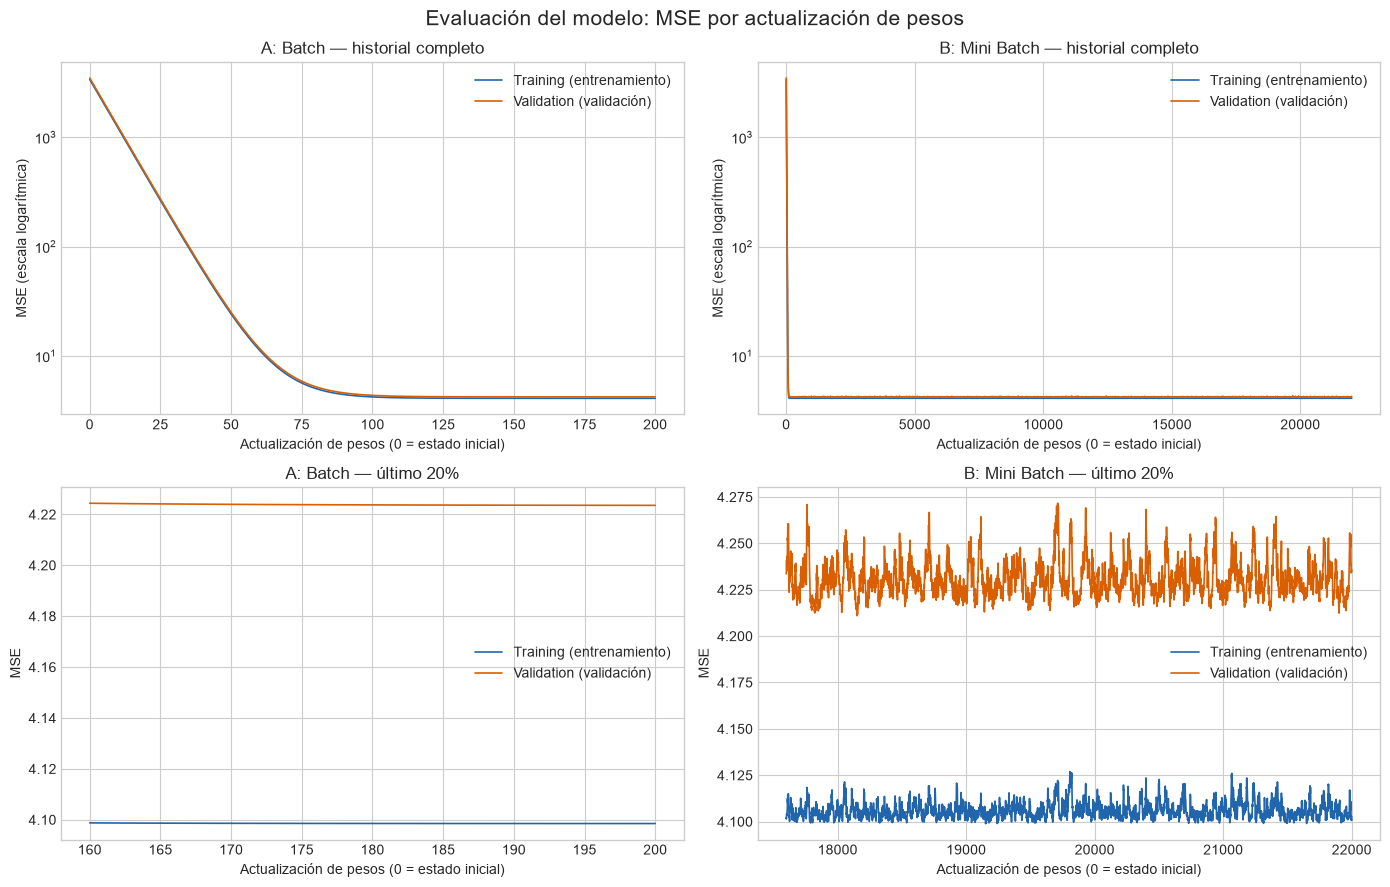

In [25]:
from pathlib import Path

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for columna, (nombre, resultado) in enumerate(experimentos.items()):
    mse_train = np.asarray(resultado["historial_mse"]["train"])
    mse_val = np.asarray(resultado["historial_mse"]["val"])
    actualizaciones = np.arange(resultado["actualizaciones"] + 1)
    assert len(mse_train) == len(mse_val) == len(actualizaciones)
    inicio_detalle = int(resultado["actualizaciones"] * 0.8)
    for fila, inicio in enumerate([0, inicio_detalle]):
        ax = axes[fila, columna]
        ax.plot(actualizaciones[inicio:], mse_train[inicio:],
                label="Training (entrenamiento)", color="#2166ac", linewidth=1.2)
        ax.plot(actualizaciones[inicio:], mse_val[inicio:],
                label="Validation (validación)", color="#d95f02", linewidth=1.2)
        ax.set_title(nombre + (" — historial completo" if fila == 0 else " — último 20%"))
        ax.set_xlabel("Actualización de pesos (0 = estado inicial)")
        ax.set_ylabel("MSE" + (" (escala logarítmica)" if fila == 0 else ""))
        if fila == 0:
            ax.set_yscale("log")
        ax.legend()
fig.suptitle("Evaluación del modelo: MSE por actualización de pesos", fontsize=15)
plt.tight_layout()
directorio_resultados = Path("resultados")
directorio_resultados.mkdir(exist_ok=True)
fig.savefig(directorio_resultados / "mse_actualizaciones.png", dpi=160, bbox_inches="tight")
plt.show()

### Comparación de entrenamiento y validación para detectar sobreajuste

La tabla informa el MSE final, la brecha `validación − entrenamiento`, el
mínimo de validación observado y la actualización donde ocurrió. También
compara el promedio de MSE del último 10% de actualizaciones con el del 10%
anterior: un cambio negativo indica descenso y uno positivo indica aumento.
Estos promedios ayudan a distinguir una tendencia de una fluctuación aislada.

Que el último MSE de validación supere su mínimo no demuestra por sí solo
sobreajuste, especialmente al observar miles de actualizaciones ruidosas.
Se deben examinar conjuntamente la magnitud, persistencia y separación de las
curvas. El mínimo se presenta como referencia; no se cambian los pesos finales
ni se seleccionan hiperparámetros a partir del conjunto de prueba.

In [26]:
filas_evaluacion = []
for nombre, resultado in experimentos.items():
    mse_train = np.asarray(resultado["historial_mse"]["train"])
    mse_val = np.asarray(resultado["historial_mse"]["val"])
    mejor_actualizacion = int(np.argmin(mse_val))
    ventana = max(1, resultado["actualizaciones"] // 10)
    cambio_train = mse_train[-ventana:].mean() - mse_train[-2 * ventana:-ventana].mean()
    cambio_val = mse_val[-ventana:].mean() - mse_val[-2 * ventana:-ventana].mean()
    filas_evaluacion.append({
        "Experimento": nombre,
        "MSE training final": mse_train[-1],
        "MSE validation final": mse_val[-1],
        "Brecha final": mse_val[-1] - mse_train[-1],
        "MSE validation mínimo": mse_val[mejor_actualizacion],
        "Actualización del mínimo": mejor_actualizacion,
        "Cambio training (último 10%)": cambio_train,
        "Cambio validation (último 10%)": cambio_val,
    })
evaluacion_mse = pd.DataFrame(filas_evaluacion).set_index("Experimento")
display(evaluacion_mse.round(6))

,MSE training final,MSE validation final,Brecha final,MSE validation mínimo,Actualización del mínimo,Cambio training (último 10%),Cambio validation (último 10%)
Experimento,,,,,,,
A: Batch,4.098491,4.223544,0.125053,4.223544,200,-0.000091,-0.000349
B: Mini Batch,4.102753,4.235927,0.133174,4.210951,18152,0.000812,0.000602


**Interpretación de esta ejecución (semilla 42, α = 0.05, 200 épocas):**

- **Batch:** el MSE final es 4.09849 en entrenamiento y 4.22354 en validación,
  con una brecha de 0.12505. Ambos errores disminuyen y se estabilizan;
  el mínimo de validación ocurre en la actualización final (200).
- **Mini Batch:** el MSE final es 4.10275 en entrenamiento y 4.23593 en
  validación, con una brecha de 0.13317. El mínimo de validación observado
  es 4.21095 en la actualización 18152. Las curvas finales oscilan alrededor
  de niveles estables. Los cambios entre los dos últimos tramos del 10%
  son pequeños: +0.00081 en entrenamiento y +0.00060 en validación.

**No se observan señales claras de sobreajuste en esta ejecución:** no hay
una subida sostenida del error de validación acompañada de una reducción
del error de entrenamiento y una brecha creciente. Las oscilaciones de
Mini Batch son compatibles con sus actualizaciones por minilotes y su tasa
constante. Esta conclusión se limita a la configuración y partición usadas;
si se cambian, se deben revisar nuevamente las curvas y la tabla.

### Predicciones frente a valores reales en prueba

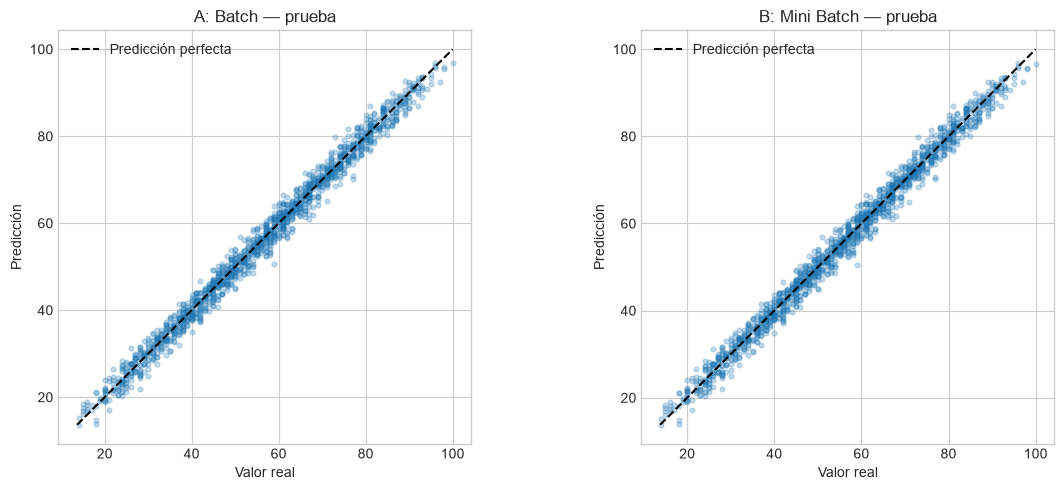

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (nombre, resultado) in zip(axes, experimentos.items()):
    predicciones = X_test @ resultado["beta"]
    ax.scatter(y_test, predicciones, alpha=0.25, s=12)
    limites = [min(y_test.min(), predicciones.min()), max(y_test.max(), predicciones.max())]
    ax.plot(limites, limites, "k--", label="Predicción perfecta")
    ax.set_title(nombre + " — prueba")
    ax.set_xlabel("Valor real")
    ax.set_ylabel("Predicción")
    ax.set_aspect("equal", adjustable="box")
    ax.legend()
plt.tight_layout()
plt.show()

### Parámetros aprendidos e interpretación

Para expresar la ecuación en las unidades originales se transforma cada
coeficiente como $\beta_j^{original}=\beta_j/\sigma_j$ y el intercepto como
$\beta_0^{original}=\beta_0-\sum_j\mu_j\beta_j/\sigma_j$.
La actividad extracurricular conserva la codificación No = 0, Yes = 1.

In [28]:
coeficientes = {}
for nombre, resultado in experimentos.items():
    beta = resultado["beta"]
    pendientes = beta[1:] / escala_train
    intercepto = beta[0] - media_train @ pendientes
    coeficientes[nombre] = np.concatenate([[intercepto], pendientes])
pd.DataFrame(coeficientes, index=["Intercepto"] + columnas_x).round(5)

,A: Batch,B: Mini Batch
Intercepto,-34.10834,-33.98346
Hours Studied,2.84577,2.83006
Previous Scores,1.01915,1.01881
Extracurricular Activities,0.62069,0.65956
Sleep Hours,0.48312,0.47011
Sample Question Papers Practiced,0.19158,0.20474


### Lectura de la comparación

Batch usa el gradiente completo y produce una trayectoria suave con esta tasa
de aprendizaje. Mini Batch realiza más actualizaciones por época y puede
acercarse al mínimo en menos épocas, pero el muestreo introduce oscilaciones
con una tasa constante. Por ello, deben compararse también el tiempo y la
cantidad de actualizaciones, además del error final.

El resumen siguiente se calcula a partir de esta ejecución. Las diferencias
pequeñas entre errores no bastan para declarar superioridad general de un
método; harían falta repeticiones con otras semillas y mediciones de tiempo.

In [29]:
for nombre in experimentos:
    validacion = comparacion.loc[(nombre, "Validación")]
    prueba = comparacion.loc[(nombre, "Prueba")]
    print(f"{nombre}: RMSE validación = {validacion['RMSE']:.4f}; "
          f"RMSE prueba = {prueba['RMSE']:.4f}; R² prueba = {prueba['R2']:.5f}")

rmse_a = comparacion.loc[("A: Batch", "Prueba"), "RMSE"]
rmse_b = comparacion.loc[("B: Mini Batch", "Prueba"), "RMSE"]
print(f"Diferencia absoluta de RMSE de prueba: {abs(rmse_b - rmse_a):.4f}")

A: Batch: RMSE validación = 2.0551; RMSE prueba = 2.0809; R² prueba = 0.98813
B: Mini Batch: RMSE validación = 2.0581; RMSE prueba = 2.0809; R² prueba = 0.98814
Diferencia absoluta de RMSE de prueba: 0.0001
